In [1]:
import numpy as np
import pandas as pd
from caveclient import CAVEclient
from meshparty.skeleton import Skeleton
import os
import pickle
import matplotlib.pyplot as plt
import myelin_analysis
import plotly.express as px
from lookup_activity_by_pt_root_id import *

#for debugging
import importlib


In [ ]:
client = CAVEclient('minnie65_public')
client.version = 1507
cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')
nucleus_df = client.materialize.query_table('nucleus_detection_v0')



In [ ]:
#0.1 Filter df for hva.

center_hva_x_z_microns = [1250,750]
radius_microns = 100

#filter nucleus_df to only include those within radius_microns of center_hva_x_z_microns, a column.
#But first, pt_position is in voxels. Need to convert to microns by multiplying by [4,4,40] and divide by 1000
nucleus_df['x_um'] = nucleus_df['pt_position'].apply(lambda pos: pos[0] * 4 / 1000)
nucleus_df['y_um'] = nucleus_df['pt_position'].apply(lambda pos: pos[1] * 4 / 1000)
nucleus_df['z_um'] = nucleus_df['pt_position'].apply(lambda pos: pos[2] * 40 / 1000)
nucleus_df['distance_from_hva_center'] = nucleus_df.apply(lambda row: np.sqrt((row['x_um'] - center_hva_x_z_microns[0])**2 + (row['z_um'] - center_hva_x_z_microns[1])**2), axis=1)
nucleus_df_hva = nucleus_df[nucleus_df['distance_from_hva_center'] <= radius_microns]



In [25]:
#0.15 See how many pt_root_ids in synapse_len_delay_1507 are also in nucleus_df_hva

count = 0
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in nucleus_df_hva['pt_root_id'].tolist():
            count += 1
print(count)

40


In [26]:
#0.2 Load only the neurons' synapses whose cell bodies sit in hva.

synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in nucleus_df_hva['pt_root_id'].tolist():
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)

print(len(synapse_delay_df))

32199


In [27]:
#Get unique pt_root_ids in synapse_delay_df
pt_root_ids_in_synapse_delay_df = synapse_delay_df['pre_pt_root_id'].unique().tolist()
print(len(pt_root_ids_in_synapse_delay_df))

#print counts of cell types of these pt_root_ids
cell_type_counts = cell_type_df[cell_type_df['pt_root_id'].isin(pt_root_ids_in_synapse_delay_df)]['cell_type'].value_counts()
print(cell_type_counts)

40
cell_type
23P      27
4P        5
5P-IT     4
5P-ET     2
MC        1
BC        1
Name: count, dtype: int64


In [28]:
#1.0 Create 3d scatter plot of synapse positions, colored by delay.

# Convert positions into separate columns
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(synapse_delay_df['pre_pt_position'].tolist(), index=synapse_delay_df.index)

# x_min, x_max = 1100, 1500
x_min, x_max = 0, 1500

# Filter by X only
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

fig = px.scatter_3d(
    # synapse_delay_df,
    filtered_x_df,
    x='x', y='y', z='z',
    color='delay',
    color_continuous_scale='viridis',
    size_max=2, opacity=0.7,
    range_color=[2, 6]
    # range_color=[0, 2]
)

fig.update_traces(marker=dict(size=2))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    title='Synapse Positions Colored by Delay'
)

fig.show()

In [29]:
#1.2 Try doing it with difference between delay and unmyelinated delay.

# Expand positions into x, y, z columns
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(
    synapse_delay_df['pre_pt_position'].tolist(),
    index=synapse_delay_df.index
)

# Create new column for difference
synapse_delay_df['delay_diff'] = synapse_delay_df['delay_unmyelin'] - synapse_delay_df['delay']

x_min, x_max = 0, 1500
# x_min, x_max = 0, 1500

# Filter by X only
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

fig = px.scatter_3d(
    # synapse_delay_df,
    filtered_x_df,
    x='x', y='y', z='z',
    color='delay_diff',
    color_continuous_scale='viridis',
    size_max=2, opacity=0.7,
    # range_color=[2, 6]
    range_color=[0, 1.5]
)

fig.update_traces(marker=dict(size=2))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    title='Synapse Positions Colored by Delay Difference (unmyel - delay)',
    coloraxis_colorbar=dict(title="Delay Difference (ms)")
)

fig.show()


In [30]:
#3.3 Plot only synapses with large delay difference.

# Filter only synapses where delay_diff > thresh

thresh_diff = 1.5

x_min, x_max = 0, 1500
# x_min, x_max = 0, 1500


# filtered_df = synapse_delay_df[synapse_delay_df['delay_diff'] > thresh_diff]
# filtered_df = synapse_delay_df[synapse_delay_df['delay'] > 3]

filtered_df = synapse_delay_df[
    (synapse_delay_df['delay'] >= 0) & (synapse_delay_df['delay'] <= 100)
]


filtered_df = filtered_df[
    (filtered_df['x'] >= x_min) & (filtered_df['x'] <= x_max)
].copy()

# Remove unknown synapses
filtered_df = filtered_df[
    filtered_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
]

#filter based on cell type to include. cell_type_df has for pt_root_id, and use pre_pt_root_id in synapse_delay_df
# Example: only include if cell type is 23P
# cell_types_to_include = ['23P']  # Example cell types
# pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()

# filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

# #Now filter for only one random pt_root_id, selected from the unique root ids in filtered_df
# #pick one random pt_root_id
# import random
# random_pt_root_id = random.choice(filtered_df['pre_pt_root_id'].unique())
# filtered_df = filtered_df[filtered_df['pre_pt_root_id'] == random_pt_root_id]



#print number of excitatory and inhibitory synapses in filtered_df
print("Number of excitatory synapses:", (filtered_df['post_excit_inhib'] == 'excitatory_neuron').sum())
print("Number of inhibitory synapses:", (filtered_df['post_excit_inhib'] == 'inhibitory_neuron').sum())
print('ratio of exc to inh:', (filtered_df['post_excit_inhib'] == 'excitatory_neuron').sum() / (filtered_df['post_excit_inhib'] == 'inhibitory_neuron').sum())

# 3D scatter plot, colored by delay difference
fig = px.scatter_3d(
    filtered_df,
    x='x', y='y', z='z',
    color='delay_diff',
    # color_discrete_map={'excitatory_neuron': 'blue', 'inhibitory_neuron': 'red'},
    # color_continuous_scale='RdBu',
    color_continuous_scale='viridis',
    opacity=0.7,
    size_max=4
)

fig.update_traces(marker=dict(size=1))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    # title= f'Synapse Positions (delay_diff > {thresh_diff} ms)',
    coloraxis_colorbar=dict(title="Delay Difference (ms)")
)

fig.show()



Number of excitatory synapses: 19305
Number of inhibitory synapses: 5173
ratio of exc to inh: 3.7318770539338875


In [31]:
#1.35 Above thresh one color - orange, below another, purple

thresh_diff = 1
# x_min, x_max = 800, 1500
x_min, x_max = 0, 1500

# Filter to X range first
filtered_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
].copy()

# #filter based on cell type to include. cell_type_df has for pt_root_id, and use pre_pt_root_id in synapse_delay_df
# # Example: only include if cell type is 23P
# cell_types_to_include = ['23P']  # Example cell types
# pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
# filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

# Add category column based on threshold
filtered_df['diff_category'] = filtered_df['delay_diff'].apply(
    lambda x: 'above' if x > thresh_diff else 'below'
)

# #print neurons above thresh
# print(filtered_df[filtered_df['diff_category'] == 'above']['pre_pt_root_id'].unique())

# 3D scatter plot with discrete colors
fig = px.scatter_3d(
    filtered_df,
    x='x', y='y', z='z',
    color='diff_category',
    color_discrete_map={'above': 'orange', 'below': 'purple'},
    opacity=0.7,
    size_max=2
)

fig.update_traces(marker=dict(size=1))
fig.update_layout(
    scene=dict(
        xaxis_title="X (microns)",
        yaxis_title="Y (microns)",
        zaxis_title="Z (microns)"
    ),
    title=f'Synapse Positions (X in {x_min}-{x_max}, delay_diff threshold = {thresh_diff} ms)'
)

fig.show()


# Reciprocal Connectivity and Myelination Interareal

In [66]:
#2.01 Filter df for hva.

center_hva_x_z_microns = [1250,750]
# center_hva_x_z_microns = [750,930]
radius_microns = 250

center_v1_x_z_microns = [750,930]
radius_v1_microns = 250

#filter nucleus_df to only include those within radius_microns of center_hva_x_z_microns, a column.
#But first, pt_position is in voxels. Need to convert to microns by multiplying by [4,4,40] and divide by 1000
nucleus_df['x_um'] = nucleus_df['pt_position'].apply(lambda pos: pos[0] * 4 / 1000)
nucleus_df['y_um'] = nucleus_df['pt_position'].apply(lambda pos: pos[1] * 4 / 1000)
nucleus_df['z_um'] = nucleus_df['pt_position'].apply(lambda pos: pos[2] * 40 / 1000)
nucleus_df['distance_from_hva_center'] = nucleus_df.apply(lambda row: np.sqrt((row['x_um'] - center_hva_x_z_microns[0])**2 + (row['z_um'] - center_hva_x_z_microns[1])**2), axis=1)
nucleus_df_hva = nucleus_df[nucleus_df['distance_from_hva_center'] <= radius_microns]

nucleus_df['distance_from_v1_center'] = nucleus_df.apply(lambda row: np.sqrt((row['x_um'] - center_v1_x_z_microns[0])**2 + (row['z_um'] - center_v1_x_z_microns[1])**2), axis=1)
nucleus_df_v1 = nucleus_df[nucleus_df['distance_from_v1_center'] <= radius_v1_microns]


#Load only the neurons' synapses whose cell bodies sit in hva and v1.
synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in nucleus_df_hva['pt_root_id'].tolist():
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_hva_df = pd.concat(synapse_delay_list, ignore_index=True)
synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in nucleus_df_v1['pt_root_id'].tolist():
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_v1_df = pd.concat(synapse_delay_list, ignore_index=True)


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_43486/3244495798.py:40: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_43486/3244495798.py:40: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_43486/3244495798.py:40: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or a

In [67]:
#2.02 Get and print unique pt_root_ids in synapse_delay_hva_df and synapse_delay_v1_df

pt_root_ids_in_synapse_delay_hva_df = synapse_delay_hva_df['pre_pt_root_id'].unique().tolist()
pt_root_ids_in_synapse_delay_v1_df = synapse_delay_v1_df['pre_pt_root_id'].unique().tolist()
print("Number of unique pt_root_ids in HVA df:", len(pt_root_ids_in_synapse_delay_hva_df))
print("Number of unique pt_root_ids in V1 df:", len(pt_root_ids_in_synapse_delay_v1_df))

Number of unique pt_root_ids in HVA df: 106
Number of unique pt_root_ids in V1 df: 310


In [68]:
#2.1 Get only neurons projecting between areas.

# Now, filter synapse_delay_v1_df to only include synapses where post_pt_root_id is in pt_root_ids_in_synapse_delay_hva_df
synapse_delay_v1_df = synapse_delay_v1_df[synapse_delay_v1_df['post_pt_root_id'].isin(pt_root_ids_in_synapse_delay_hva_df)]
print("Number of V1 to HVA projecting neurons:", len(synapse_delay_v1_df['pre_pt_root_id'].unique().tolist()))

#Now do the same for hva to v1.
synapse_delay_hva_df = synapse_delay_hva_df[synapse_delay_hva_df['post_pt_root_id'].isin(pt_root_ids_in_synapse_delay_v1_df)]
print("Number of HVA to V1 projecting neurons:", len(synapse_delay_hva_df['pre_pt_root_id'].unique().tolist()))

Number of V1 to HVA projecting neurons: 55
Number of HVA to V1 projecting neurons: 40


In [69]:
2.2 #Now get an adjacency matrix of the connections between the two areas.
# Rows are V1 neurons, columns are HVA neurons. Value is number of synapses
v1_to_hva_adj_matrix = pd.DataFrame(0, index=synapse_delay_v1_df['pre_pt_root_id'].unique(), columns=synapse_delay_v1_df['post_pt_root_id'].unique())
for _, row in synapse_delay_v1_df.iterrows():
    v1_to_hva_adj_matrix.at[row['pre_pt_root_id'], row['post_pt_root_id']] += 1

# Now, rows are HVA neurons, columns are V1 neurons. Value is number of synapses
hva_to_v1_adj_matrix = pd.DataFrame(0, index=synapse_delay_hva_df['pre_pt_root_id'].unique(), columns=synapse_delay_hva_df['post_pt_root_id'].unique())
for _, row in synapse_delay_hva_df.iterrows():
    hva_to_v1_adj_matrix.at[row['pre_pt_root_id'], row['post_pt_root_id']] += 1

#print shapes of both adjacency matrices
print("V1 to HVA adjacency matrix shape:", v1_to_hva_adj_matrix.shape)
print("HVA to V1 adjacency matrix shape:", hva_to_v1_adj_matrix.shape)


V1 to HVA adjacency matrix shape: (55, 71)
HVA to V1 adjacency matrix shape: (40, 80)


In [ ]:
# print(v1_to_hva_adj_matrix[864691135585046648][864691135447638356])

0


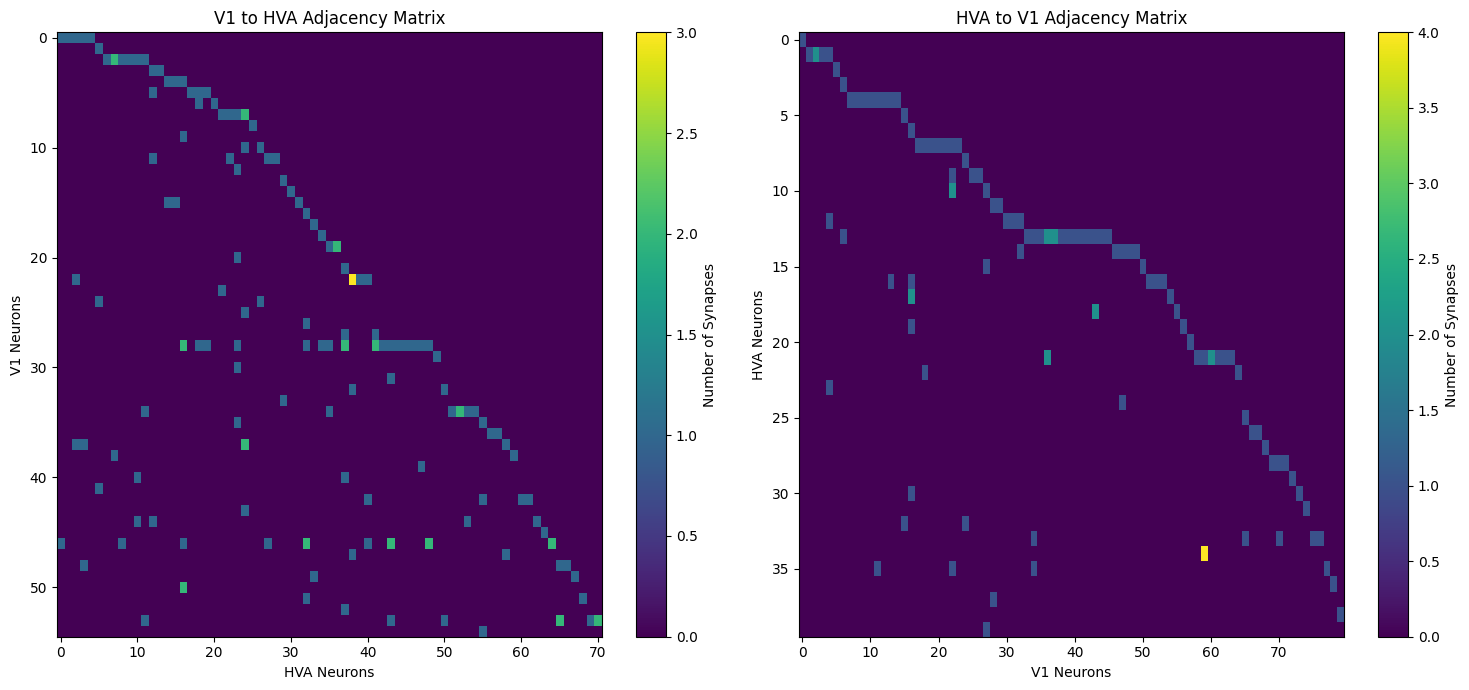

In [70]:
#2.25 Visualize both adjacency matrices as heatmaps using matplotlib
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
im1 = axes[0].imshow(v1_to_hva_adj_matrix, aspect='auto', cmap='viridis')
axes[0].set_title('V1 to HVA Adjacency Matrix')
axes[0].set_xlabel('HVA Neurons')
axes[0].set_ylabel('V1 Neurons')
fig.colorbar(im1, ax=axes[0], label='Number of Synapses')

im2 = axes[1].imshow(hva_to_v1_adj_matrix, aspect='auto', cmap='viridis')
axes[1].set_title('HVA to V1 Adjacency Matrix')
axes[1].set_xlabel('V1 Neurons')
axes[1].set_ylabel('HVA Neurons')
fig.colorbar(im2, ax=axes[1], label='Number of Synapses')
plt.tight_layout()
plt.show()


In [76]:
#this is getting probability of an interareal neuron synapsing onto a neuron in other area.

#print number of nonzero entries in each adjacency matrix
print("Number of connections (nonzero entries) in V1 to HVA adjacency matrix:", np.count_nonzero(v1_to_hva_adj_matrix.values))
print("Number of connections (nonzero entries) in HVA to V1 adjacency matrix:", np.count_nonzero(hva_to_v1_adj_matrix.values))

#print probability of connection from one area to the other
print("Probability of connection from V1 to HVA:", np.count_nonzero(v1_to_hva_adj_matrix.values) / (v1_to_hva_adj_matrix.shape[0] * v1_to_hva_adj_matrix.shape[1]))
print("Probability of connection from HVA to V1:", np.count_nonzero(hva_to_v1_adj_matrix.values) / (hva_to_v1_adj_matrix.shape[0] * hva_to_v1_adj_matrix.shape[1]))


#chances of V1 interareal neurons synapsing onto HVA interareal neurons
#ie, how many values of v1_to_hva are in index of hva_to_v1?
v1_interareal_neurons = set(v1_to_hva_adj_matrix.index)
hva_interareal_neurons = set(hva_to_v1_adj_matrix.index)
v1_intereal_neurons_targets = set(v1_to_hva_adj_matrix.columns)
hva_intereal_neurons_targets = set(hva_to_v1_adj_matrix.columns)
v1_proj_to_hva_proj = v1_intereal_neurons_targets.intersection(hva_interareal_neurons)
print("Number of hva interareal neurons that recieve input from v1:", len(v1_proj_to_hva_proj))

#chances of HVA interareal neurons synapsing onto V1 interareal neurons
hva_proj_to_v1_proj = hva_intereal_neurons_targets.intersection(v1_interareal_neurons)
print("Number of v1 interareal neurons that recieve input from hva:", len(hva_proj_to_v1_proj))

#Probability of connection from V1 interareal neurons to HVA interareal neurons
#take v1_to_hva_adj_matrix and only include columns that are in hva_interareal_neurons, then get number of nonzero entries divided by total possible connections
v1_to_hva_proj_adj_matrix = v1_to_hva_adj_matrix[v1_to_hva_adj_matrix.columns.intersection(hva_interareal_neurons)]
print("Probability of connection from V1 interareal neurons to HVA interareal neurons:", np.count_nonzero(v1_to_hva_proj_adj_matrix.values) / (v1_to_hva_proj_adj_matrix.shape[0] * v1_to_hva_proj_adj_matrix.shape[1]))
#Probability of connection from HVA interareal neurons to V1 interareal neurons
hva_to_v1_proj_adj_matrix = hva_to_v1_adj_matrix[hva_to_v1_adj_matrix.columns.intersection(v1_interareal_neurons)]
print("Probability of connection from HVA interareal neurons to V1 interareal neurons:", np.count_nonzero(hva_to_v1_proj_adj_matrix.values) / (hva_to_v1_proj_adj_matrix.shape[0] * hva_to_v1_proj_adj_matrix.shape[1]))





Number of connections (nonzero entries) in V1 to HVA adjacency matrix: 138
Number of connections (nonzero entries) in HVA to V1 adjacency matrix: 107
Probability of connection from V1 to HVA: 0.0353393085787452
Probability of connection from HVA to V1: 0.0334375
Number of hva interareal neurons that recieve input from v1: 28
Number of v1 interareal neurons that recieve input from hva: 13
Probability of connection from V1 interareal neurons to HVA interareal neurons: 0.03961038961038961
Probability of connection from HVA interareal neurons to V1 interareal neurons: 0.04423076923076923


In [71]:
#Now figure out how many reciprocal connections there are.
# A reciprocal connection is when a neuron in V1 connects to a neuron in HVA, and that same neuron in HVA connects back to that same neuron in V1.
reciprocal_connections = 0
for v1_neuron in v1_to_hva_adj_matrix.index:
    for hva_neuron in v1_to_hva_adj_matrix.columns:
        #if hva neuron or v1 neuron not in the other adjacency matrix, skip
        if hva_neuron not in hva_to_v1_adj_matrix.index or v1_neuron not in hva_to_v1_adj_matrix.columns:
            continue
        if v1_to_hva_adj_matrix.at[v1_neuron, hva_neuron] > 0 and hva_to_v1_adj_matrix.at[hva_neuron, v1_neuron] > 0:
            reciprocal_connections += 1
print("Number of reciprocal connections:", reciprocal_connections)

Number of reciprocal connections: 0


# Receptive field, Orientation tuning, myelin analyses

In [77]:
#3.0

digital_twin_coreg_df = client.materialize.query_table('digital_twin_properties_bcm_coreg_v4')

myelin_info_df = myelin_analysis.create_myelin_info_df("segments_myelin_1507", cell_type_df)




Table Owner Notice on digital_twin_properties_bcm_coreg_v4:  For the use of this table please cite: 1) https://doi.org/10.1038/s41586-025-08829-y; Wang et al., 2025 2) https://doi.org/10.1038/s41586-025-08840-3; Ding, Fahey, and Papadopoulos et al., 2025 3) https://doi.org/10.1038/s41586-025-08790-w; MICrONS Consortium et al., 2025


864691135739733140
864691136041000190
864691135938604804
864691136578982164
864691135209715577
864691135700409211
864691136176327430
864691135417236410
864691135572385061
864691136196131542
864691135867009413
864691135572346349
864691135699487522
864691135233242713


/Users/charlesshvartsman/Library/Mobile Documents/com~apple~CloudDocs/Documents/phd_work/Sinha/myelin/MICrONS_Analysis/Myelin_Extract/myelin_analysis.py:60: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



864691135725838763
864691136194355176
864691136134678667
864691135778465376
864691135430186032
864691136309871706
864691135356753871
864691135875121038
864691135915343462
864691135258083503
864691135928938196
864691135105897037
864691136991390869
864691136137834877
864691136927176778
864691135719761713
864691135274038801
864691136389679223
864691135256861871
864691135919645872
864691135083577335
864691135325071004
864691136674080135
864691136391623039
864691136034011579
864691135341198789
864691135716428314
864691135688350944
864691135447638356
864691135273655569
864691136603342033
864691135692949951
864691135294935564
864691136389878647
864691135655526082
864691136023889209
864691135782702387
864691134966005023
864691135891467401
864691135492804327
864691136904615602
864691135773910603
864691136023980601
864691135852138183
864691136053374451
864691135271282085
864691135271696549
864691135339982310
864691135868118038
864691135741458324
864691136108071129
864691135811260876
864691135656

In [78]:
myelin_info_df.head()

,pt_root_id,total_myelin_length,cell_type,number_of_segments
0,864691135739733140,221.03,4P,29
1,864691136041000190,0.00,6P-IT,63
2,864691135938604804,279.49,23P,104
3,864691136578982164,0.00,4P,69
4,864691135209715577,0.00,6P-IT,9


In [79]:
digital_twin_coreg_df.head()

,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,...,cc_abs,cc_max,cc_norm,OSI,DSI,readout_loc_x,readout_loc_y,pt_position,bb_start_position,bb_end_position
0,335649,2020-09-28 22:41:20.303372+00:00,t,295.861125,93747454767483710,864691135702330235,4641,2025-07-30 17:51:26.519437+00:00,t,335649,...,0.500382,0.754597,0.663112,0.189591,0.248792,-0.144415,0.059087,"[210784, 182032, 22673]","[nan, nan, nan]","[nan, nan, nan]"
1,194144,2020-09-28 22:42:01.511773+00:00,t,213.307228,83542405709639148,864691135614842827,12061,2025-07-30 17:52:11.181987+00:00,t,194144,...,0.432421,0.534646,0.808799,0.610376,0.134852,-0.245233,-0.201346,"[136400, 170640, 17951]","[nan, nan, nan]","[nan, nan, nan]"
2,293318,2020-09-28 22:45:23.572432+00:00,t,430.108180,90783515419343652,864691135430194992,14936,2025-07-30 17:52:13.397517+00:00,t,293318,...,0.320471,0.532293,0.602058,0.009774,0.327494,-0.135235,0.026081,"[189472, 119296, 26037]","[nan, nan, nan]","[nan, nan, nan]"
3,488652,2020-09-28 22:41:44.769373+00:00,t,328.244265,104297405805551073,864691135565621079,4550,2025-07-30 17:51:26.448354+00:00,t,488652,...,0.330611,0.639865,0.516689,0.363019,0.598630,-0.026693,0.027254,"[287536, 142464, 19382]","[nan, nan, nan]","[nan, nan, nan]"
4,332833,2020-09-28 22:44:41.864456+00:00,t,274.418729,93535317407139914,864691135387371905,8441,2025-07-30 17:51:50.670362+00:00,t,332833,...,0.363243,0.551817,0.658267,0.637795,0.463199,-0.151180,-0.083915,"[209328, 174304, 20004]","[nan, nan, nan]","[nan, nan, nan]"


In [121]:
#print all columns of digital_twin_coreg_df
print(digital_twin_coreg_df.columns)

Index(['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_supervoxel_id',
       'pt_root_id', 'id', 'created', 'valid', 'target_id', 'session',
       'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs',
       'cc_max', 'cc_norm', 'OSI', 'DSI', 'readout_loc_x', 'readout_loc_y',
       'pt_position', 'bb_start_position', 'bb_end_position'],
      dtype='object')


In [173]:
#3.1 Merge myelin_info_df and digital_twin_coreg_df on pt_root_id
merged_df = pd.merge(myelin_info_df, digital_twin_coreg_df, on='pt_root_id', how='inner')
print("Merged df shape:", merged_df.shape)

# Filter for cell_type = 23P
cell_types_to_include = ['4P']  # Example cell types
pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
merged_df = merged_df[merged_df['pt_root_id'].isin(pt_root_ids_to_include)]

# #Filter for pt_root_ids in v1_interareal_neurons or hva_interareal_neurons
# merged_df = merged_df[merged_df['pt_root_id'].isin(v1_interareal_neurons.union(hva_interareal_neurons))]

#filter for pt_root_ids in v1_interareal_neurons
# merged_df = merged_df[merged_df['pt_root_id'].isin(hva_interareal_neurons)]

#filter for neurons in nucleus_df_v1
# merged_df = merged_df[merged_df['pt_root_id'].isin(nucleus_df_hva['pt_root_id'].tolist())]

print("Merged df shape after filtering:", merged_df.shape)

Merged df shape: (338, 30)
Merged df shape after filtering: (38, 30)


In [ ]:
import pingouin as pg
import pandas as pd

# Prepare numeric columns
cols = ['total_myelin_length', 'DSI', 'number_of_segments']
df = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()

# Compute partial correlation (control for number_of_segments)
pcorr = pg.partial_corr(data=df, x='DSI', y='total_myelin_length', covar='number_of_segments', method='pearson')
print(pcorr)


           n         r         CI95%     p-val
pearson  222  0.215411  [0.09, 0.34]  0.001273


In [171]:
import pingouin as pg
import pandas as pd

# Prepare numeric and clean data
cols = ['DSI', 'number_of_segments', 'total_myelin_length']
df = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()

# Compute partial correlation (control for total_myelin_length)
pcorr = pg.partial_corr(data=df, x='DSI', y='number_of_segments', covar='total_myelin_length', method='pearson')

print(pcorr)


           n         r         CI95%     p-val
pearson  222  0.196565  [0.07, 0.32]  0.003343
